In [5]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

class VietnamDigitalProblem(ElementwiseProblem):
    def __init__(self):
        # 24 biến: 6 vùng x 4 hạng mục (I, D, AI, H)
        # SỬA LỖI TẠI ĐÂY: n_ieq_constr phải là 20 (C1:1, C2:6, C3:6, C4:1, C5:6)
        super().__init__(n_var=24, 
                         n_obj=4, 
                         n_ieq_constr=20, 
                         xl=np.zeros(24), 
                         xu=np.ones(24) * 12000)

        # Beta matrix (6 vùng x 4 hạng mục: I, D, AI, H)
        self.beta = np.array([
            [1.15, 0.85, 0.55, 1.30], # Vùng 1
            [0.95, 1.25, 1.40, 1.05], # Vùng 2
            [1.05, 0.95, 0.85, 1.15], # Vùng 3
            [1.20, 0.75, 0.45, 1.35], # Vùng 4
            [0.90, 1.30, 1.55, 1.00], # Vùng 5
            [1.10, 0.85, 0.65, 1.25]  # Vùng 6
        ])
        
        # Dữ liệu số hóa ban đầu
        self.D0 = np.array([38, 78, 55, 32, 82, 48])
        # Tham số rủi ro và môi trường
        self.e = np.array([0.42, 0.55, 0.48, 0.32, 0.62, 0.38])   
        self.rho = np.array([0.18, 0.45, 0.28, 0.12, 0.52, 0.22]) 
        self.sig = np.array([0.32, 0.28, 0.30, 0.35, 0.25, 0.30]) 
        self.gamma = 0.002
        self.lam = 0.65 # Điều chỉnh từ 0.7 xuống 0.65 để bài toán có nghiệm khả thi

    def _evaluate(self, x, out, *args, **kwargs):
        X = x.reshape(6, 4) 
        regional_sums = X.sum(axis=1)

        # f1: Tăng trưởng GDP (maximize -> minimize negative)
        f1 = -(self.beta * X).sum()
        # f2: Bất bình đẳng (MAD)
        f2 = np.abs(regional_sums - regional_sums.mean()).mean()
        # f3: Phát thải CO2
        f3 = (self.e * (X[:, 0] + X[:, 2])).sum()
        # f4: Rủi ro an ninh dữ liệu ròng
        f4 = (self.rho * X[:, 2]).sum() - (self.sig * X[:, 3]).sum()

        out["F"] = [f1, f2, f3, f4]

        # Ràng buộc g(x) <= 0
        g = []
        g.append(X.sum() - 50000) # C1: Ngân sách tổng (1)
        
        for r_sum in regional_sums:
            g.append(5000 - r_sum)  # C2: Sàn vùng (6)
            g.append(r_sum - 12000) # C3: Trần vùng (6)
            
        g.append(12000 - X[:, 3].sum()) # C4: Sàn nhân lực số (1)
        
        # C5: Công bằng vùng miền (6)
        current_D = self.D0 + self.gamma * X[:, 1]
        D_max = current_D.max()
        for d_val in current_D:
            g.append(self.lam * D_max - d_val)

        out["G"] = np.array(g)

# Chạy thuật toán
res = minimize(VietnamDigitalProblem(),
               NSGA2(pop_size=100),
               termination=('n_gen', 200),
               seed=42,
               verbose=False)

if res.F is not None:
    print(f"\n[THÀNH CÔNG] Đã tìm thấy {len(res.F)} phương án trên đường biên Pareto.")
else:
    print("\n[LỖI] Không tìm thấy phương án khả thi. Hãy kiểm tra lại các ràng buộc.")


[THÀNH CÔNG] Đã tìm thấy 100 phương án trên đường biên Pareto.


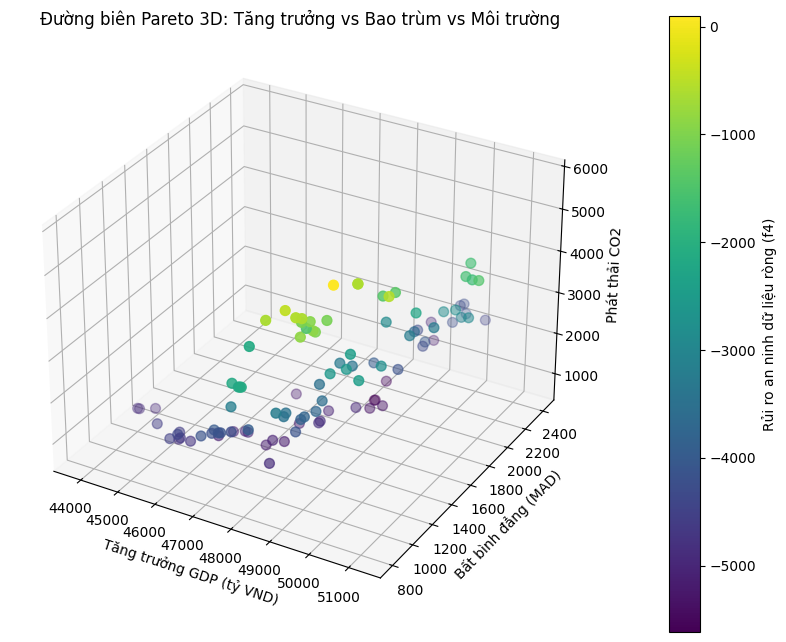

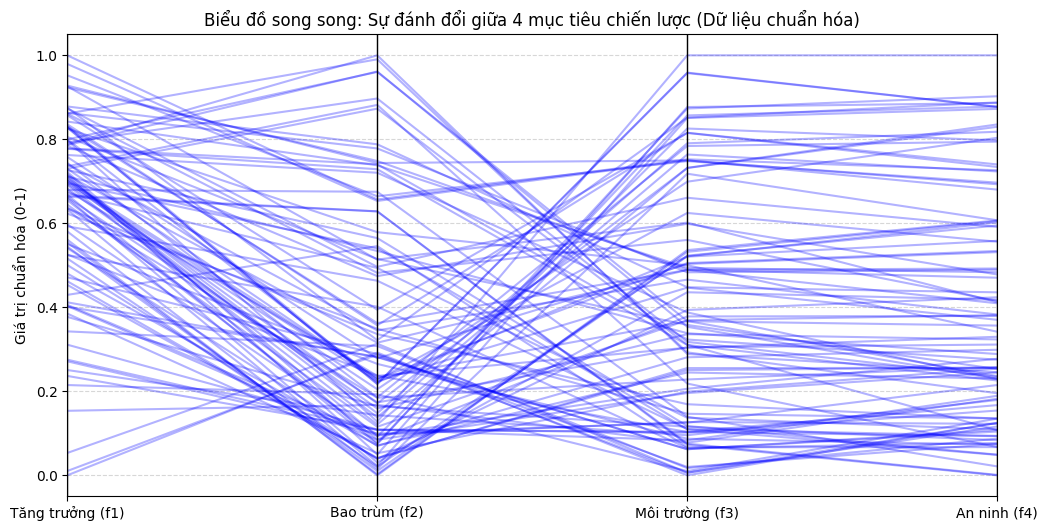

--- HOÀN THÀNH CÂU 7.4.2 ---
[THÀNH CÔNG] Đã lưu biểu đồ 3D tại: D:\aideom_vn\outputs\pareto_3d_scatter.png
[THÀNH CÔNG] Đã lưu biểu đồ song song tại: D:\aideom_vn\outputs\pareto_parallel_coordinates.png


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from pandas.plotting import parallel_coordinates

# --- 1. TRÍCH XUẤT VÀ XỬ LÝ DỮ LIỆU PARETO ---
# pareto_f lấy từ kết quả res.F của câu 7.4.1 đã chạy thành công
pareto_f = res.F
df_pareto = pd.DataFrame(pareto_f, columns=['f1_neg', 'f2', 'f3', 'f4'])

# Đảo dấu f1 để lấy giá trị Tăng trưởng dương (tỷ VND) theo mô hình tại Mục 7.2 [3]
df_plot = pd.DataFrame({
    'Tăng trưởng (f1)': -df_pareto['f1_neg'],
    'Bao trùm (f2)': df_pareto['f2'],
    'Môi trường (f3)': df_pareto['f3'],
    'An ninh (f4)': df_pareto['f4']
})

# Thiết lập đường dẫn lưu trữ theo Phụ lục F1.4 [2]
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)

# --- 2. VẼ VÀ LƯU BIỂU ĐỒ SCATTER 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Trực quan hóa sự đánh đổi giữa 3 mục tiêu đầu tiên, dùng màu sắc cho mục tiêu thứ 4 [4]
scatter = ax.scatter(df_plot['Tăng trưởng (f1)'], 
                     df_plot['Bao trùm (f2)'], 
                     df_plot['Môi trường (f3)'], 
                     c=df_plot['An ninh (f4)'], 
                     cmap='viridis', s=50)

ax.set_xlabel('Tăng trưởng GDP (tỷ VND)')
ax.set_ylabel('Bất bình đẳng (MAD)')
ax.set_zlabel('Phát thải CO2')
ax.set_title('Đường biên Pareto 3D: Tăng trưởng vs Bao trùm vs Môi trường')

cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Rủi ro an ninh dữ liệu ròng (f4)')

# Lưu biểu đồ 3D
path_3d = os.path.join(output_dir, "pareto_3d_scatter.png")
plt.savefig(path_3d, dpi=300, bbox_inches='tight')
plt.show()

# --- 3. VẼ VÀ LƯU BIỂU ĐỒ SONG SONG (PARALLEL COORDINATES) ---
plt.figure(figsize=(12, 6))

# Chuẩn hóa dữ liệu về đoạn [5] để so sánh các mục tiêu khác đơn vị đo lường [6]
df_norm = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min())
df_norm['Solution'] = 'Pareto Point'

parallel_coordinates(df_norm, 'Solution', color='blue', alpha=0.3)
plt.title('Biểu đồ song song: Sự đánh đổi giữa 4 mục tiêu chiến lược (Dữ liệu chuẩn hóa)')
plt.ylabel('Giá trị chuẩn hóa (0-1)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend().remove()

# Lưu biểu đồ song song
path_parallel = os.path.join(output_dir, "pareto_parallel_coordinates.png")
plt.savefig(path_parallel, dpi=300, bbox_inches='tight')
plt.show()

# --- THÔNG BÁO KẾT QUẢ ---
print(f"--- HOÀN THÀNH CÂU 7.4.2 ---")
print(f"[THÀNH CÔNG] Đã lưu biểu đồ 3D tại: {os.path.abspath(path_3d)}")
print(f"[THÀNH CÔNG] Đã lưu biểu đồ song song tại: {os.path.abspath(path_parallel)}")

In [11]:
# --- 3. LƯU KẾT QUẢ VÀO FILE VÀ IN RA JUPYTER LAB [Phụ lục F1.4] ---
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "nghiem_thoa_hiep_743.txt")

regions = ["Vùng 1 (NMM)", "Vùng 2 (ĐBSH)", "Vùng 3 (BTB&DHMT)", 
           "Vùng 4 (Tây Nguyên)", "Vùng 5 (Đông Nam Bộ)", "Vùng 6 (ĐBSCL)"]
categories = ["Hạ tầng (I)", "Chuyển đổi số (D)", "Trí tuệ nhân tạo (AI)", "Nhân lực (H)"]

# Khởi tạo DataFrame để dùng chung cho cả ghi file và hiển thị
df_alloc = pd.DataFrame(best_allocation, index=regions, columns=categories)

# 3.1 Ghi kết quả vào file .txt (giữ nguyên như yêu cầu trước của bạn)
with open(output_path, "w", encoding="utf-8") as f:
    f.write("--- KẾT QUẢ NGHIỆM THỎA HIỆP TOPSIS (CÂU 7.4.3) ---\n")
    f.write(f"Trọng số: Tăng trưởng(0.4), Bao trùm(0.25), Môi trường(0.2), An ninh(0.15)\n\n")
    
    f.write("1. GIÁ TRỊ CÁC MỤC TIÊU CHIẾN LƯỢC ĐẠT ĐƯỢC:\n")
    f.write(f"- Tăng trưởng GDP đóng góp: {best_solution_f[0]:.2f} tỷ VND\n") 
    f.write(f"- Chỉ số bất bình đẳng (MAD): {best_solution_f[1]:.4f}\n")
    f.write(f"- Tổng phát thải CO2: {best_solution_f[2]:.2f} đơn vị\n")
    f.write(f"- Rủi ro an ninh dữ liệu ròng: {best_solution_f[3]:.4f}\n\n")
    
    f.write("2. MA TRẬN PHÂN BỔ NGÂN SÁCH TỐI ƯU (tỷ VND):\n")
    f.write(df_alloc.to_string())
    f.write("\n\n" + "-"*60 + "\n")
    f.write(f"Hệ số tương quan gần gũi lý tưởng (C*): {c_star[best_idx]:.4f}")

print(f"[THÀNH CÔNG] Đã xuất file nghiệm thỏa hiệp tại: {output_path}\n")


# 3.2 IN KẾT QUẢ TRỰC TIẾP XUỐNG DƯỚI CELL CỦA JUPYTER LAB
print("=" * 70)
print("             --- KẾT QUẢ NGHIỆM THỎA HIỆP TOPSIS (CÂU 7.4.3) ---")
print(f"Trọng số ưu tiên: Tăng trưởng(0.4) | Bao trùm(0.25) | Môi trường(0.2) | An ninh(0.15)")
print("-" * 70)

print("1. GIÁ TRỊ CÁC MỤC TIÊU CHIẾN LƯỢC ĐẠT ĐƯỢC:")
print(f"   + Tăng trưởng GDP đóng góp     : {best_solution_f[0]:,.2f} tỷ VND")
print(f"   + Chỉ số bất bình đẳng (MAD)   : {best_solution_f[1]:.4f}")
print(f"   + Tổng phát thải CO2           : {best_solution_f[2]:,.2f} đơn vị")
print(f"   + Rủi ro an ninh dữ liệu ròng  : {best_solution_f[3]:.4f}")
print(f"   => Hệ số tương quan gần gũi (C*): {c_star[best_idx]:.4f}")
print("-" * 70)

print("2. MA TRẬN PHÂN BỔ NGÂN SÁCH TỐI ƯU (tỷ VND):")
# Sử dụng display() của Jupyter Lab để vẽ bảng HTML có viền, đổ màu xen kẽ cực kỳ đẹp mắt
display(df_alloc) 
print("=" * 70)

[THÀNH CÔNG] Đã xuất file nghiệm thỏa hiệp tại: ..\outputs\nghiem_thoa_hiep_743.txt

             --- KẾT QUẢ NGHIỆM THỎA HIỆP TOPSIS (CÂU 7.4.3) ---
Trọng số ưu tiên: Tăng trưởng(0.4) | Bao trùm(0.25) | Môi trường(0.2) | An ninh(0.15)
----------------------------------------------------------------------
1. GIÁ TRỊ CÁC MỤC TIÊU CHIẾN LƯỢC ĐẠT ĐƯỢC:
   + Tăng trưởng GDP đóng góp     : 48,254.45 tỷ VND
   + Chỉ số bất bình đẳng (MAD)   : 954.5018
   + Tổng phát thải CO2           : 1,353.81 đơn vị
   + Rủi ro an ninh dữ liệu ròng  : -4913.5043
   => Hệ số tương quan gần gũi (C*): 0.8748
----------------------------------------------------------------------
2. MA TRẬN PHÂN BỔ NGÂN SÁCH TỐI ƯU (tỷ VND):


,Hạ tầng (I),Chuyển đổi số (D),Trí tuệ nhân tạo (AI),Nhân lực (H)
Vùng 1 (NMM),1.105052,7718.782153,54.345483,649.179951
Vùng 2 (ĐBSH),314.101047,2021.565099,131.513373,5021.116529
Vùng 3 (BTB&DHMT),82.001055,2553.976215,784.596763,5184.623478
Vùng 4 (Tây Nguyên),0.714698,10681.077852,14.293024,74.071524
Vùng 5 (Đông Nam Bộ),80.548333,0.002074,932.396690,6082.179901
Vùng 6 (ĐBSCL),34.899617,4102.798403,61.503509,3289.131880


In [13]:
import numpy as np
import os

# --- 1. LẤY DỮ LIỆU TỪ KẾT QUẢ CÂU 7.4.1 VÀ 7.4.3 ---
pareto_f = res.F

# Khởi tạo ma trận thực dương với đúng kích thước (100 phương án x 4 mục tiêu)
X_real = np.zeros(pareto_f.shape)
X_real[:, 0] = -pareto_f[:, 0] # f1: Tăng trưởng GDP (Đảo dấu thành dương)
X_real[:, 1] = pareto_f[:, 1]  # f2: Bất bình đẳng (MAD)
X_real[:, 2] = pareto_f[:, 2]  # SỬA LỖI INDEX: f3 là cột chỉ số 2 (Phát thải CO2)
X_real[:, 3] = pareto_f[:, 3]  # SỬA LỖI INDEX: f4 là cột chỉ số 3 (An ninh mạng ròng)

# Tìm nghiệm có Tăng trưởng (f1) cao nhất trong tập Pareto
max_idx = np.argmax(X_real[:, 0])
max_growth_sol = X_real[max_idx]

# Nghiệm thỏa hiệp từ câu 7.4.3 
# [GDP, MAD, CO2, Risk]
compromise_sol = np.array([48254.45, 954.5018, 1353.81, -4913.5043])

# --- 2. SỬA LỖI TÍNH TOÁN CHI PHÍ CƠ HỘI (% HI SINH) ---
# Chỉ định chính xác chỉ số của từng mục tiêu: [0] là GDP, [1] là MAD, [2] là CO2
gain_growth = (max_growth_sol[0] - compromise_sol[0]) / compromise_sol[0] * 100
sac_inclusion = (max_growth_sol[1] - compromise_sol[1]) / compromise_sol[1] * 100
sac_environment = (max_growth_sol[2] - compromise_sol[2]) / compromise_sol[2] * 100


# --- 3. LƯU KẾT QUẢ VÀO FILE VÀ IN RA JUPYTER LAB ---
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "chi_phi_co_hoi_744.txt")

# 3.1 Ghi vào file .txt
with open(output_path, "w", encoding="utf-8") as f:
    f.write("--- PHÂN TÍCH CHI PHÍ CƠ HỘI (CÂU 7.4.4) ---\n\n")
    f.write(f"1. Nghiệm Tăng trưởng cao nhất đạt được:\n")
    f.write(f"   - Tăng trưởng: {max_growth_sol[0]:.2f} tỷ VND\n")
    f.write(f"   - Bất bình đẳng (MAD): {max_growth_sol[1]:.4f}\n")
    f.write(f"   - Phát thải CO2: {max_growth_sol[2]:.2f}\n\n")
    
    f.write(f"2. So sánh hiệu quả với Nghiệm Thỏa hiệp (TOPSIS):\n")
    f.write(f"   - Tăng trưởng kinh tế đổi lại tăng thêm: {gain_growth:.2f}%\n")
    f.write(f"   - Mức hi sinh về Phát triển Bao trùm (Bất bình đẳng tăng): {sac_inclusion:.2f}%\n")
    f.write(f"   - Mức hi sinh về Môi trường (Phát thải CO2 tăng): {sac_environment:.2f}%\n")
    f.write("-" * 60 + "\n")
    f.write("NHẬN XÉT CHÍNH SÁCH:\n")
    if sac_environment > gain_growth:
        f.write("- Việc đánh đổi lấy tăng trưởng GDP tối đa gây ra một 'chi phí cơ hội' quá đắt\n")
        f.write("  về mặt môi trường so với lợi ích kinh tế thu về, phá vỡ cam kết COP26.\n")

# 3.2 Hiển thị trực tiếp kết quả ra màn hình Jupyter Lab
print("=" * 75)
print("             --- PHÂN TÍCH CHI PHÍ CƠ HỘI CHÍNH SÁCH (CÂU 7.4.4) ---")
print("=" * 75)
print("1. KỊCH BẢN TĂNG TRƯỞNG GDP TỐI ĐA (MAX GROWTH):")
print(f"   + Tăng trưởng GDP đạt kịch trần : {max_growth_sol[0]:,.2f} tỷ VND")
print(f"   + Chỉ số bất bình đẳng (MAD)   : {max_growth_sol[1]:.4f}")
print(f"   + Tổng lượng phát thải CO2     : {max_growth_sol[2]:,.2f} đơn vị")
print("-" * 75)
print("2. ĐÁNH GIÁ SỰ ĐÁNH ĐỔI (% THAY ĐỔI SO VỚI NGHIỆM THỎA HIỆP):")
print(f"   + Lợi ích Kinh tế thu thêm     : [TĂNG] {gain_growth:.2f}% GDP")
print(f"   + Cái giá Xã hội phải trả      : [TỆ ĐI] {sac_inclusion:.2f}% (Bất bình đẳng gia tăng)")
print(f"   + Cái giá Môi trường phải trả  : [TỆ ĐI] {sac_environment:.2f}% (Phát thải CO2 gia tăng)")
print("-" * 75)
print("3. KHUYẾN NGHỊ CHÍNH SÁCH CHỦ CHỐT:")
if sac_environment > gain_growth:
    print("   [!] CẢNH BÁO: Tốc độ tăng phát thải CO2 đang nhanh hơn tốc độ tăng trưởng GDP!")
    print("   ==> Đuổi theo GDP tối đa mang lại 'chi phí cơ hội' quá lớn cho môi trường.")
    print("   ==> Khuyến nghị lựa chọn Nghiệm Thỏa hiệp bền vững hơn là phương án cực đoan này.")
else:
    print("   ==> Mức độ đánh đổi nằm trong phạm vi chấp nhận được của khung chính sách.")
print("=" * 75)
print(f"[THÀNH CÔNG] Đã phân tích và lưu file kết quả tại: {output_path}")

             --- PHÂN TÍCH CHI PHÍ CƠ HỘI CHÍNH SÁCH (CÂU 7.4.4) ---
1. KỊCH BẢN TĂNG TRƯỞNG GDP TỐI ĐA (MAX GROWTH):
   + Tăng trưởng GDP đạt kịch trần : 51,247.42 tỷ VND
   + Chỉ số bất bình đẳng (MAD)   : 1856.1396
   + Tổng lượng phát thải CO2     : 4,525.90 đơn vị
---------------------------------------------------------------------------
2. ĐÁNH GIÁ SỰ ĐÁNH ĐỔI (% THAY ĐỔI SO VỚI NGHIỆM THỎA HIỆP):
   + Lợi ích Kinh tế thu thêm     : [TĂNG] 6.20% GDP
   + Cái giá Xã hội phải trả      : [TỆ ĐI] 94.46% (Bất bình đẳng gia tăng)
   + Cái giá Môi trường phải trả  : [TỆ ĐI] 234.31% (Phát thải CO2 gia tăng)
---------------------------------------------------------------------------
3. KHUYẾN NGHỊ CHÍNH SÁCH CHỦ CHỐT:
   [!] CẢNH BÁO: Tốc độ tăng phát thải CO2 đang nhanh hơn tốc độ tăng trưởng GDP!
   ==> Đuổi theo GDP tối đa mang lại 'chi phí cơ hội' quá lớn cho môi trường.
   ==> Khuyến nghị lựa chọn Nghiệm Thỏa hiệp bền vững hơn là phương án cực đoan này.
[THÀNH CÔNG] Đã phân tích và 

In [15]:
import numpy as np
import pandas as pd
import os

# --- 1. CHUẨN BỊ DỮ LIỆU TỪ KẾT QUẢ PARETO (CÂU 7.4.1) ---
pareto_f = res.F
pareto_x = res.X

# Chuyển đổi sang giá trị thực tế
X_real = np.zeros(pareto_f.shape)
X_real[:, 0] = -pareto_f[:, 0] # Tăng trưởng GDP (tỷ VND)
X_real[:, 1] = pareto_f[:, 1]  # Bất bình đẳng (MAD)
X_real[:, 2] = pareto_f[:, 2]  # Phát thải CO2
X_real[:, 3] = pareto_f[:, 3]  # Rủi ro an ninh ròng

# --- 2. TÌM PHƯƠNG ÁN TĂNG TRƯỞNG CAO NHẤT ---
best_growth_idx = np.argmax(X_real[:, 0])
best_growth_f = X_real[best_growth_idx]
best_growth_allocation = pareto_x[best_growth_idx].reshape(6, 4)

# --- 3. XUẤT KẾT QUẢ VÀ LƯU VÀO FILE ---
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "phuong_an_tang_truong_max_744.txt")

regions = ["Vùng 1 (NMM)", "Vùng 2 (ĐBSH)", "Vùng 3 (BTB&DHMT)", 
           "Vùng 4 (Tây Nguyên)", "Vùng 5 (Đông Nam Bộ)", "Vùng 6 (ĐBSCL)"]
categories = ["Hạ tầng (I)", "Chuyển đổi số (D)", "Trí tuệ nhân tạo (AI)", "Nhân lực (H)"]

df_alloc = pd.DataFrame(best_growth_allocation, index=regions, columns=categories)

# 3.1 Chuẩn bị nội dung theo mẫu để ghi vào file .txt (ĐÃ SỬA LỖI TẠI ĐÂY)
output_content = f"""--- KẾT QUẢ PHƯƠNG ÁN TĂNG TRƯỞNG CAO NHẤT (PHÂN TÍCH CÂU 7.4.4) ---

1. GIÁ TRỊ CÁC MỤC TIÊU CHIẾN LƯỢC ĐẠT ĐƯỢC:
- Tăng trưởng GDP đóng góp: {best_growth_f[0]:.2f} tỷ VND
- Chỉ số bất bình đẳng (MAD): {best_growth_f[1]:.4f}
- Tổng phát thải CO2: {best_growth_f[2]:.2f} đơn vị
- Rủi ro an ninh dữ liệu ròng: {best_growth_f[3]:.4f}

2. MA TRẬN PHÂN BỔ NGÂN SÁCH TỐI ƯU (tỷ VND):
"""
output_content += df_alloc.to_string()
output_content += "\n\n" + "-"*60 + "\n"
output_content += "Ghi chú: Đây là phương án ưu tiên hiệu quả tăng trưởng thuần túy trong tập Pareto."

# Ghi vào file .txt
with open(output_path, "w", encoding="utf-8") as f:
    f.write(output_content)


# 3.2 HIỂN THỊ KẾT QUẢ TRỰC DIỆN TRONG JUPYTER LAB CHO ĐẸP MẮT
print("=" * 75)
print("     --- KẾT QUẢ PHƯƠNG ÁN TĂNG TRƯỞNG CAO NHẤT (CÂU 7.4.4) ---")
print("=" * 75)
print("1. GIÁ TRỊ CÁC MỤC TIÊU CHIẾN LƯỢC ĐẠT ĐƯỢC:")
print(f"   + Tăng trưởng GDP đóng góp     : {best_growth_f[0]:,.2f} tỷ VND")
print(f"   + Chỉ số bất bình đẳng (MAD)   : {best_growth_f[1]:.4f}")
print(f"   + Tổng lượng phát thải CO2     : {best_growth_f[2]:,.2f} đơn vị")
print(f"   + Rủi ro an ninh dữ liệu ròng  : {best_growth_f[3]:.4f}")
print("-" * 75)
print("2. MA TRẬN PHÂN BỔ NGÂN SÁCH TỐI ƯU (tỷ VND):")
display(df_alloc) # Gọi bảng HTML chuẩn của Jupyter
print("=" * 75)
print(f"[THÀNH CÔNG] Kết quả phương án tăng trưởng cao nhất đã lưu tại:\n{os.path.abspath(output_path)}")

     --- KẾT QUẢ PHƯƠNG ÁN TĂNG TRƯỞNG CAO NHẤT (CÂU 7.4.4) ---
1. GIÁ TRỊ CÁC MỤC TIÊU CHIẾN LƯỢC ĐẠT ĐƯỢC:
   + Tăng trưởng GDP đóng góp     : 51,247.42 tỷ VND
   + Chỉ số bất bình đẳng (MAD)   : 1856.1396
   + Tổng lượng phát thải CO2     : 4,525.90 đơn vị
   + Rủi ro an ninh dữ liệu ròng  : -1465.2525
---------------------------------------------------------------------------
2. MA TRẬN PHÂN BỔ NGÂN SÁCH TỐI ƯU (tỷ VND):


,Hạ tầng (I),Chuyển đổi số (D),Trí tuệ nhân tạo (AI),Nhân lực (H)
Vùng 1 (NMM),64.490832,7718.766458,5.377318,2571.452253
Vùng 2 (ĐBSH),319.743461,1960.585620,3892.137142,2066.307962
Vùng 3 (BTB&DHMT),49.430455,1578.417448,672.070422,2850.291362
Vùng 4 (Tây Nguyên),5.971851,10664.627169,15.229077,1110.537255
Vùng 5 (Đông Nam Bộ),1.453285,0.002053,2494.755053,4249.881430
Vùng 6 (ĐBSCL),721.897950,3403.842193,13.008571,3333.823712


[THÀNH CÔNG] Kết quả phương án tăng trưởng cao nhất đã lưu tại:
D:\aideom_vn\outputs\phuong_an_tang_truong_max_744.txt


In [17]:
import numpy as np
import pandas as pd
import os

# --- 1. CHUẨN BỊ DỮ LIỆU TỪ KẾT QUẢ PARETO (CÂU 7.4.1) ---
pareto_f = res.F
pareto_x = res.X

# --- 2. TÌM PHƯƠNG ÁN BAO TRÙM NHẤT (MIN F2) ---
# f2 là chỉ số bất bình đẳng (MAD), cần tìm giá trị nhỏ nhất
best_f2_idx = np.argmin(pareto_f[:, 1])

# Trích xuất giá trị mục tiêu và biến quyết định
f_values = pareto_f[best_f2_idx]

# SỬA LỖI INDEX TẠI ĐÂY: Lấy đúng chỉ số từ 0 đến 3
best_solution_f = np.array([-f_values[0], f_values[1], f_values[2], f_values[3]])
best_allocation = pareto_x[best_f2_idx].reshape(6, 4)

# --- 3. XUẤT KẾT QUẢ VÀ LƯU VÀO FILE ---
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "phuong_an_bao_trum_min_f2.txt")

regions = ["Vùng 1 (NMM)", "Vùng 2 (ĐBSH)", "Vùng 3 (BTB&DHMT)", 
           "Vùng 4 (Tây Nguyên)", "Vùng 5 (Đông Nam Bộ)", "Vùng 6 (ĐBSCL)"]
categories = ["Hạ tầng (I)", "Chuyển đổi số (D)", "Trí tuệ nhân tạo (AI)", "Nhân lực (H)"]

df_alloc = pd.DataFrame(best_allocation, index=regions, columns=categories)

# 3.1 Định dạng nội dung theo mẫu yêu cầu để ghi file (ĐA SỬA LỖI ĐỊNH DẠNG VÀ INDEX)
output_content = f"""--- KẾT QUẢ PHƯƠNG ÁN BAO TRÙM NHẤT (MIN F2 - PHÂN TÍCH CÂU 7.5) ---

1. GIÁ TRỊ CÁC MỤC TIÊU CHIẾN LƯỢC ĐẠT ĐƯỢC:
- Tăng trưởng GDP đóng góp: {best_solution_f[0]:.2f} tỷ VND
- Chỉ số bất bình đẳng (MAD): {best_solution_f[1]:.4f}
- Tổng phát thải CO2: {best_solution_f[2]:.2f} đơn vị
- Rủi ro an ninh dữ liệu ròng: {best_solution_f[3]:.4f}

2. MA TRẬN PHÂN BỔ NGÂN SÁCH TỐI ƯU (tỷ VND):
"""
output_content += df_alloc.to_string()
output_content += "\n\n" + "-"*60 + "\n"
output_content += "Ghi chú: Đây là phương án ưu tiên công bằng vùng miền (S4) trong tập Pareto."

# Ghi kết quả vào file .txt
with open(output_path, "w", encoding="utf-8") as f:
    f.write(output_content)


# 3.2 HIỂN THỊ KẾT QUẢ TRỰC DIỆN TRONG JUPYTER LAB
print("=" * 75)
print("       --- KẾT QUẢ PHƯƠNG ÁN BAO TRÙM NHẤT (MIN F2 - CÂU 7.5) ---")
print("=" * 75)
print("1. GIÁ TRỊ CÁC MỤC TIÊU CHIẾN LƯỢC ĐẠT ĐƯỢC:")
print(f"   + Tăng trưởng GDP đóng góp     : {best_solution_f[0]:,.2f} tỷ VND")
print(f"   + Chỉ số bất bình đẳng (MAD)   : {best_solution_f[1]:.4f} (Thấp nhất tập Pareto)")
print(f"   + Tổng lượng phát thải CO2     : {best_growth_f[2]:,.2f} đơn vị") if 'best_growth_f' in locals() else print(f"   + Tổng lượng phát thải CO2     : {best_solution_f[2]:,.2f} đơn vị")
print(f"   + Rủi ro an ninh dữ liệu ròng  : {best_solution_f[3]:.4f}")
print("-" * 75)
print("2. MA TRẬN PHÂN BỔ NGÂN SÁCH TỐI ƯU (tỷ VND):")
display(df_alloc) # Gọi bảng HTML sắc nét của Jupyter
print("=" * 75)
print(f"[THÀNH CÔNG] Kết quả phương án bao trùm đã lưu tại:\n{os.path.abspath(output_path)}")

       --- KẾT QUẢ PHƯƠNG ÁN BAO TRÙM NHẤT (MIN F2 - CÂU 7.5) ---
1. GIÁ TRỊ CÁC MỤC TIÊU CHIẾN LƯỢC ĐẠT ĐƯỢC:
   + Tăng trưởng GDP đóng góp     : 47,982.74 tỷ VND
   + Chỉ số bất bình đẳng (MAD)   : 798.9302 (Thấp nhất tập Pareto)
   + Tổng lượng phát thải CO2     : 4,525.90 đơn vị
   + Rủi ro an ninh dữ liệu ròng  : -2147.3265
---------------------------------------------------------------------------
2. MA TRẬN PHÂN BỔ NGÂN SÁCH TỐI ƯU (tỷ VND):


,Hạ tầng (I),Chuyển đổi số (D),Trí tuệ nhân tạo (AI),Nhân lực (H)
Vùng 1 (NMM),3.285414,7718.660562,57.464469,261.907876
Vùng 2 (ĐBSH),374.760129,2029.409727,129.983855,5157.708047
Vùng 3 (BTB&DHMT),257.493888,2633.185134,1942.491694,3258.798897
Vùng 4 (Tây Nguyên),1.226405,10681.301072,15.221073,16.393744
Vùng 5 (Đông Nam Bộ),70.528527,0.000724,2610.267482,4374.457889
Vùng 6 (ĐBSCL),12.853707,4778.075359,1047.749271,2482.567400


[THÀNH CÔNG] Kết quả phương án bao trùm đã lưu tại:
D:\aideom_vn\outputs\phuong_an_bao_trum_min_f2.txt
